# 01 — Data Understanding

## Project

**Should Marketing Professionals Learn Data Analytics?**

*A Machine Learning Analysis of Education, Technical Skills and Career Success*

## Objective

This project investigates whether education, professional preparation, technical skills and other career-related factors are associated with career success among professionals with a background in Marketing.

The analysis focuses specifically on individuals whose field of study is Marketing.

## Dataset

**Education & Career Success**

The dataset contains information about education, professional preparation, skills and career outcomes.

For this project, the analysis will be restricted to observations where:

`Field_of_Study = Marketing`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import csv

file_path = "../data/raw/education_career_success cvs.csv"

with open(file_path, "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    rows = list(reader)

print("Number of rows: - 01_data_understanding.ipynb:9", len(rows))
print("Columns in header: - 01_data_understanding.ipynb:10", len(rows[0]))

for i, row in enumerate(rows):
    if len(row) != len(rows[0]):
        print("Problem on row: - 01_data_understanding.ipynb:14", i + 1)
        print("Number of columns: - 01_data_understanding.ipynb:15", len(row))
        print("Expected: - 01_data_understanding.ipynb:16", len(rows[0]))

Number of rows: - 01_data_understanding.ipynb:9 401
Columns in header: - 01_data_understanding.ipynb:10 19


In [8]:
import os

file_path = "../data/raw/education_career_success cvs.csv"

print("File exists: - 01_data_understanding.ipynb:5", os.path.exists(file_path))
print("Full path: - 01_data_understanding.ipynb:6", os.path.abspath(file_path))

File exists: - 01_data_understanding.ipynb:5 True
Full path: - 01_data_understanding.ipynb:6 c:\Users\teres\OneDrive\Desktop\ironhack\2 ironhack BOOTCAMP Data anaytics\1 Labs\Should-Marketing-Professionals-Learn-Data-Analytics-\data\raw\education_career_success cvs.csv


In [9]:
with open(file_path, "r", encoding="utf-8") as file:
    for i in range(5):
        print(file.readline().strip())

Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No


In [11]:
df = pd.read_csv("../data/raw/education_career_success cvs.csv")

df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
1,S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
2,S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
3,S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No
4,S005,25,Male,3.7,1420,3.5,Medicine,2,6,2,8,7,3,95000,8,2,Mid,5,No


In [12]:
df.shape

(400, 19)

In [13]:
df.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'High_School_GPA',
 'SAT_Score',
 'University_GPA',
 'Field_of_Study',
 'Internships_Completed',
 'Projects_Completed',
 'Certifications',
 'Soft_Skills_Score',
 'Networking_Score',
 'Job_Offers',
 'Starting_Salary',
 'Career_Satisfaction',
 'Years_to_Promotion',
 'Current_Job_Level',
 'Work_Life_Balance',
 'Entrepreneurship']

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             400 non-null    str    
 1   Age                    400 non-null    int64  
 2   Gender                 400 non-null    str    
 3   High_School_GPA        400 non-null    float64
 4   SAT_Score              400 non-null    int64  
 5   University_GPA         400 non-null    float64
 6   Field_of_Study         400 non-null    str    
 7   Internships_Completed  400 non-null    int64  
 8   Projects_Completed     400 non-null    int64  
 9   Certifications         400 non-null    int64  
 10  Soft_Skills_Score      400 non-null    int64  
 11  Networking_Score       400 non-null    int64  
 12  Job_Offers             400 non-null    int64  
 13  Starting_Salary        400 non-null    int64  
 14  Career_Satisfaction    400 non-null    int64  
 15  Years_to_Promotio

In [15]:
df["Field_of_Study"].value_counts()

Field_of_Study
Business            72
Engineering         58
Psychology          55
Computer Science    49
Law                 44
Marketing           44
Medicine            35
Arts                32
Finance              5
Education            3
Nursing              3
Name: count, dtype: int64

In [17]:
marketing_df = df[df["Field_of_Study"] == "Marketing"].copy()

marketing_df.shape

(44, 19)

In [18]:
marketing_df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
10,S011,22,Male,3.3,1220,3.0,Marketing,1,3,1,6,5,1,40000,6,4,Entry,8,No
21,S022,24,Female,3.6,1360,3.4,Marketing,2,6,2,8,7,2,72000,7,3,Mid,7,No
30,S031,22,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No
45,S046,22,Female,3.5,1290,3.2,Marketing,2,5,2,7,6,2,64000,7,4,Mid,7,No
52,S053,23,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No


In [19]:
marketing_df.info()

<class 'pandas.DataFrame'>
Index: 44 entries, 10 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             44 non-null     str    
 1   Age                    44 non-null     int64  
 2   Gender                 44 non-null     str    
 3   High_School_GPA        44 non-null     float64
 4   SAT_Score              44 non-null     int64  
 5   University_GPA         44 non-null     float64
 6   Field_of_Study         44 non-null     str    
 7   Internships_Completed  44 non-null     int64  
 8   Projects_Completed     44 non-null     int64  
 9   Certifications         44 non-null     int64  
 10  Soft_Skills_Score      44 non-null     int64  
 11  Networking_Score       44 non-null     int64  
 12  Job_Offers             44 non-null     int64  
 13  Starting_Salary        44 non-null     int64  
 14  Career_Satisfaction    44 non-null     int64  
 15  Years_to_Promotion    

In [20]:
df["Field_of_Study"].value_counts()

Field_of_Study
Business            72
Engineering         58
Psychology          55
Computer Science    49
Law                 44
Marketing           44
Medicine            35
Arts                32
Finance              5
Education            3
Nursing              3
Name: count, dtype: int64

In [21]:
marketing_df = df[df["Field_of_Study"] == "Marketing"].copy()

marketing_df.shape

(44, 19)

In [22]:
marketing_df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
10,S011,22,Male,3.3,1220,3.0,Marketing,1,3,1,6,5,1,40000,6,4,Entry,8,No
21,S022,24,Female,3.6,1360,3.4,Marketing,2,6,2,8,7,2,72000,7,3,Mid,7,No
30,S031,22,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No
45,S046,22,Female,3.5,1290,3.2,Marketing,2,5,2,7,6,2,64000,7,4,Mid,7,No
52,S053,23,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No


In [23]:
marketing_df.info()

<class 'pandas.DataFrame'>
Index: 44 entries, 10 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             44 non-null     str    
 1   Age                    44 non-null     int64  
 2   Gender                 44 non-null     str    
 3   High_School_GPA        44 non-null     float64
 4   SAT_Score              44 non-null     int64  
 5   University_GPA         44 non-null     float64
 6   Field_of_Study         44 non-null     str    
 7   Internships_Completed  44 non-null     int64  
 8   Projects_Completed     44 non-null     int64  
 9   Certifications         44 non-null     int64  
 10  Soft_Skills_Score      44 non-null     int64  
 11  Networking_Score       44 non-null     int64  
 12  Job_Offers             44 non-null     int64  
 13  Starting_Salary        44 non-null     int64  
 14  Career_Satisfaction    44 non-null     int64  
 15  Years_to_Promotion    

## Marketing Professionals

The original dataset contains 400 observations across 19 variables and 11 fields of study.

For this project, the analysis is restricted to the 44 observations where the field of study is Marketing.

This allows the project to focus specifically on the relationship between education, professional preparation, skills and career outcomes within Marketing.

Due to the relatively small sample size, the Machine Learning results will be interpreted cautiously and considered exploratory rather than broadly generalizable.

In [24]:
marketing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,44.0,22.909091,1.459821,21.0,21.00,23.0,24.0,25.0
High_School_GPA,44.0,3.613636,0.106947,3.3,3.60,3.6,3.7,3.8
SAT_Score,44.0,1379.318182,71.735876,1220.0,1340.00,1380.0,1440.0,1520.0
University_GPA,44.0,3.431818,0.168126,3.0,3.40,3.4,3.5,3.7
Internships_Completed,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Projects_Completed,44.0,6.113636,1.204949,3.0,5.00,6.0,7.0,8.0
Certifications,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Soft_Skills_Score,44.0,7.818182,0.814769,6.0,7.00,8.0,8.0,9.0
Networking_Score,44.0,6.818182,0.814769,5.0,6.00,7.0,7.0,8.0
Job_Offers,44.0,2.613636,0.753778,1.0,2.00,3.0,3.0,4.0


In [25]:
marketing_df["Starting_Salary"].describe()

count        44.000000
mean      80318.181818
std       15108.557143
min       40000.000000
25%       72000.000000
50%       81000.000000
75%       90000.000000
max      102000.000000
Name: Starting_Salary, dtype: float64

In [26]:
marketing_df["Starting_Salary"].sort_values().to_list()

[40000,
 46000,
 46000,
 64000,
 64000,
 64000,
 64000,
 64000,
 68000,
 72000,
 72000,
 72000,
 72000,
 72000,
 76000,
 76000,
 76000,
 76000,
 78000,
 78000,
 78000,
 78000,
 84000,
 88000,
 88000,
 88000,
 88000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 94000,
 94000,
 94000,
 94000,
 94000,
 94000,
 102000,
 102000,
 102000,
 102000]

In [27]:
marketing_df["Current_Job_Level"].value_counts()

Current_Job_Level
Mid      41
Entry     3
Name: count, dtype: int64

In [28]:
marketing_df["Gender"].value_counts()

Gender
Female    27
Male      17
Name: count, dtype: int64

In [29]:
marketing_df["Entrepreneurship"].value_counts()

Entrepreneurship
No    44
Name: count, dtype: int64

In [30]:
numeric_columns = marketing_df.select_dtypes(include="number")

correlation_with_salary = (
    numeric_columns
    .corr()["Starting_Salary"]
    .sort_values(ascending=False)
)

correlation_with_salary

Starting_Salary          1.000000
University_GPA           0.916947
Career_Satisfaction      0.889081
Job_Offers               0.885040
Certifications           0.849258
Internships_Completed    0.849258
High_School_GPA          0.840661
Projects_Completed       0.838522
SAT_Score                0.831026
Networking_Score         0.828493
Soft_Skills_Score        0.828493
Age                      0.581267
Work_Life_Balance       -0.833713
Years_to_Promotion      -0.890776
Name: Starting_Salary, dtype: float64

In [31]:
marketing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,44.0,22.909091,1.459821,21.0,21.00,23.0,24.0,25.0
High_School_GPA,44.0,3.613636,0.106947,3.3,3.60,3.6,3.7,3.8
SAT_Score,44.0,1379.318182,71.735876,1220.0,1340.00,1380.0,1440.0,1520.0
University_GPA,44.0,3.431818,0.168126,3.0,3.40,3.4,3.5,3.7
Internships_Completed,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Projects_Completed,44.0,6.113636,1.204949,3.0,5.00,6.0,7.0,8.0
Certifications,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Soft_Skills_Score,44.0,7.818182,0.814769,6.0,7.00,8.0,8.0,9.0
Networking_Score,44.0,6.818182,0.814769,5.0,6.00,7.0,7.0,8.0
Job_Offers,44.0,2.613636,0.753778,1.0,2.00,3.0,3.0,4.0


In [32]:
marketing_df["Starting_Salary"].describe()

count        44.000000
mean      80318.181818
std       15108.557143
min       40000.000000
25%       72000.000000
50%       81000.000000
75%       90000.000000
max      102000.000000
Name: Starting_Salary, dtype: float64

In [33]:
marketing_df["Starting_Salary"].sort_values().to_list()

[40000,
 46000,
 46000,
 64000,
 64000,
 64000,
 64000,
 64000,
 68000,
 72000,
 72000,
 72000,
 72000,
 72000,
 76000,
 76000,
 76000,
 76000,
 78000,
 78000,
 78000,
 78000,
 84000,
 88000,
 88000,
 88000,
 88000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 94000,
 94000,
 94000,
 94000,
 94000,
 94000,
 102000,
 102000,
 102000,
 102000]

In [34]:
marketing_df["Current_Job_Level"].value_counts()

Current_Job_Level
Mid      41
Entry     3
Name: count, dtype: int64

In [35]:
marketing_df["Gender"].value_counts()

Gender
Female    27
Male      17
Name: count, dtype: int64

In [36]:
numeric_columns = marketing_df.select_dtypes(include="number")

correlation_with_salary = (
    numeric_columns
    .corr()["Starting_Salary"]
    .sort_values(ascending=False)
)

correlation_with_salary

Starting_Salary          1.000000
University_GPA           0.916947
Career_Satisfaction      0.889081
Job_Offers               0.885040
Certifications           0.849258
Internships_Completed    0.849258
High_School_GPA          0.840661
Projects_Completed       0.838522
SAT_Score                0.831026
Networking_Score         0.828493
Soft_Skills_Score        0.828493
Age                      0.581267
Work_Life_Balance       -0.833713
Years_to_Promotion      -0.890776
Name: Starting_Salary, dtype: float64

### University GPA and Starting Salary

University GPA shows the strongest correlation with Starting Salary among the numerical variables. We visualize this relationship to assess whether higher academic performance is associated with higher starting salaries among Marketing professionals.

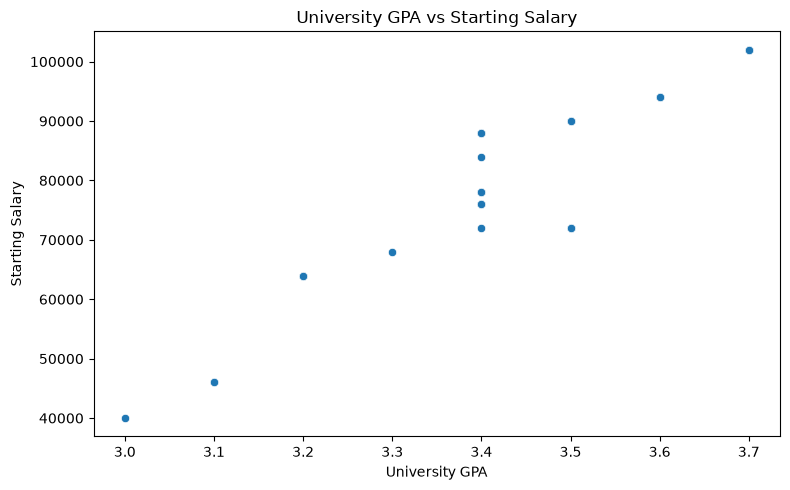

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="University_GPA",
    y="Starting_Salary"
)

plt.title("University GPA vs Starting Salary")
plt.xlabel("University GPA")
plt.ylabel("Starting Salary")
plt.tight_layout()

plt.show()

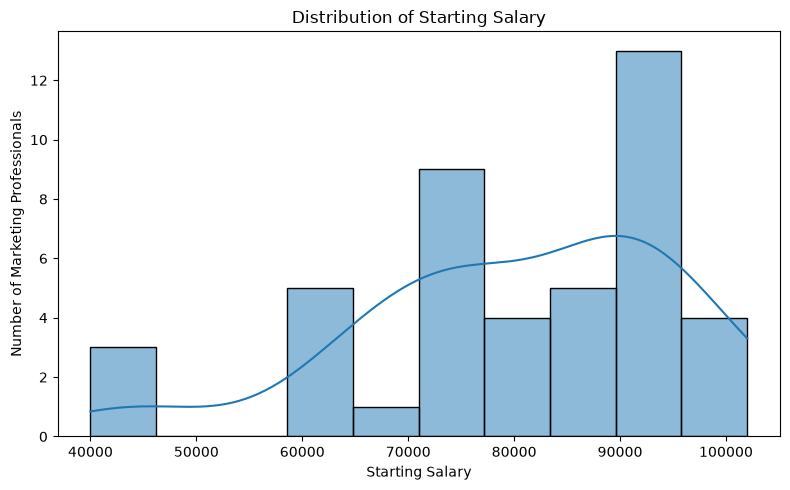

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=marketing_df,
    x="Starting_Salary",
    bins=10,
    kde=True
)

plt.title("Distribution of Starting Salary")
plt.xlabel("Starting Salary")
plt.ylabel("Number of Marketing Professionals")

plt.tight_layout()
plt.show()

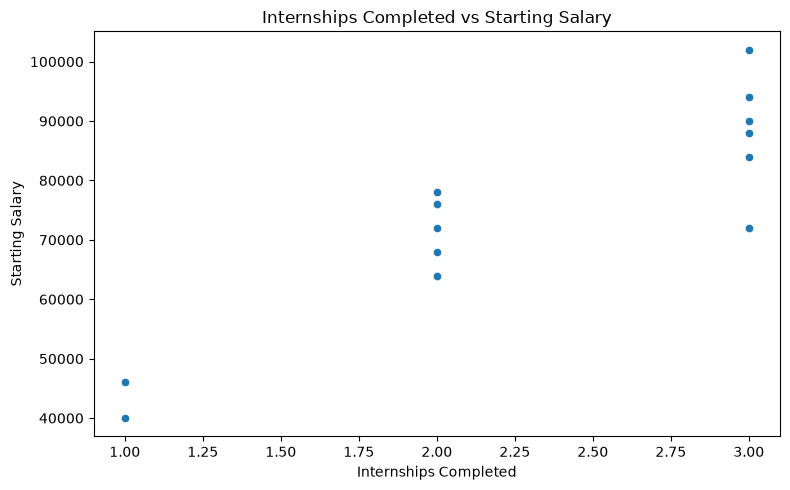

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="Internships_Completed",
    y="Starting_Salary"
)

plt.title("Internships Completed vs Starting Salary")
plt.xlabel("Internships Completed")
plt.ylabel("Starting Salary")

plt.tight_layout()
plt.show()

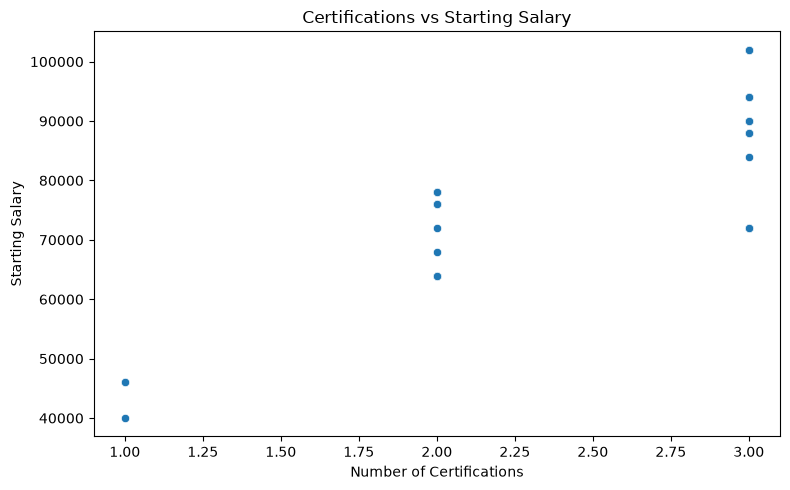

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="Certifications",
    y="Starting_Salary"
)

plt.title("Certifications vs Starting Salary")
plt.xlabel("Number of Certifications")
plt.ylabel("Starting Salary")

plt.tight_layout()
plt.show()

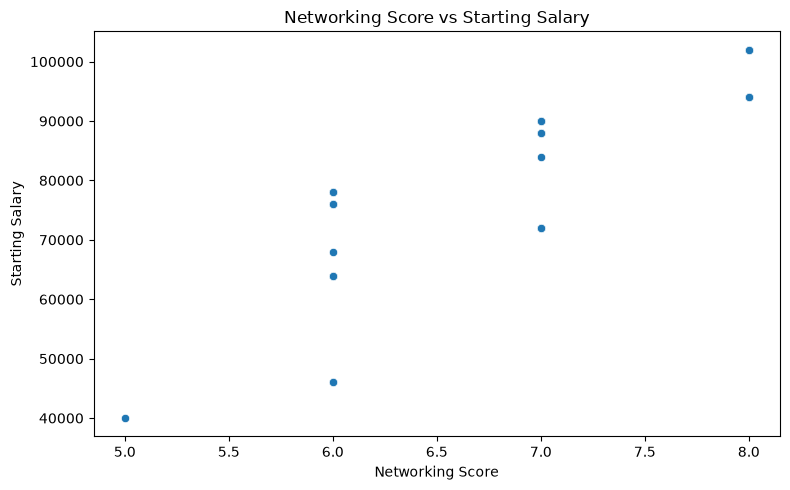

In [41]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="Networking_Score",
    y="Starting_Salary"
)

plt.title("Networking Score vs Starting Salary")
plt.xlabel("Networking Score")
plt.ylabel("Starting Salary")

plt.tight_layout()
plt.show()

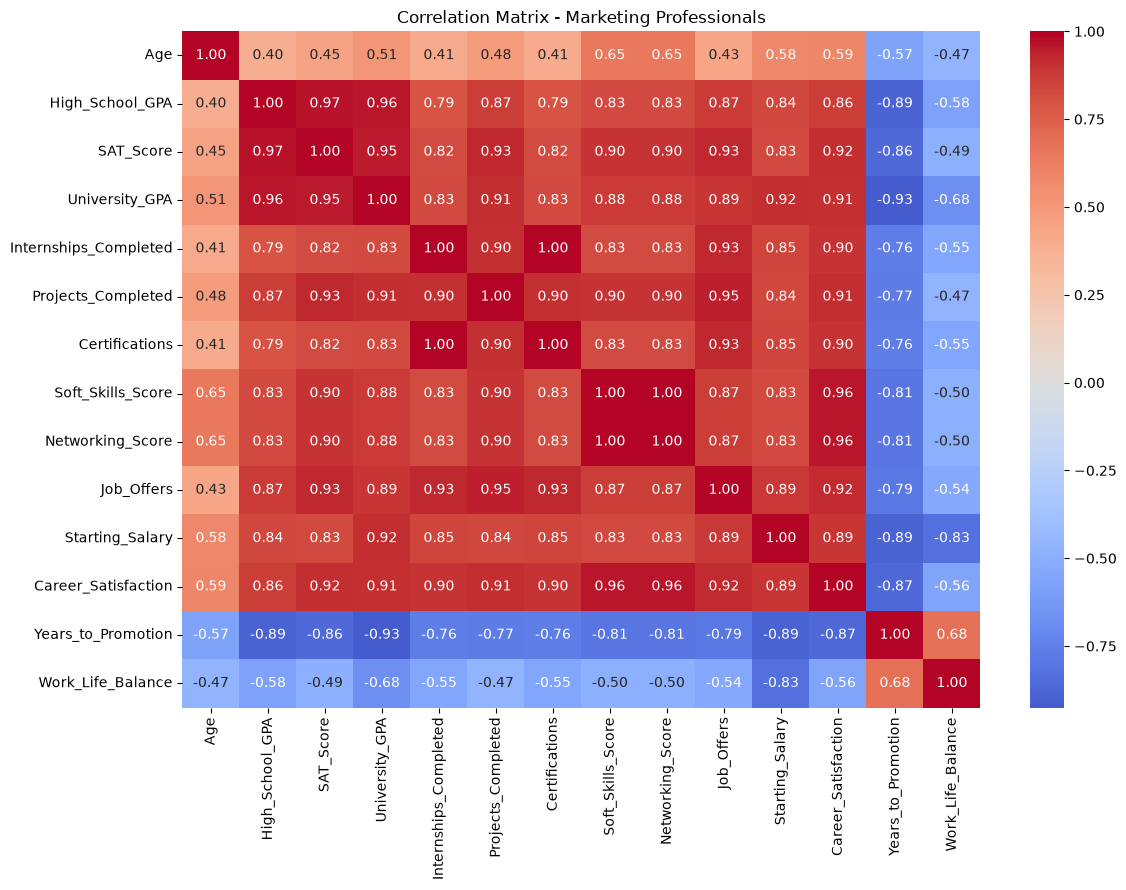

In [42]:
plt.figure(figsize=(12, 9))

correlation_matrix = marketing_df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Marketing Professionals")
plt.tight_layout()

plt.show()

In [44]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 5.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.6 MB 5.5 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 6.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 6.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 6.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = marketing_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

c:\Users\teres\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
4,Internships_Completed,inf
6,Certifications,inf
7,Soft_Skills_Score,3.385589e+06
8,Networking_Score,2.589467e+06
2,SAT_Score,1.474218e+02
3,University_GPA,1.133241e+02
5,Projects_Completed,6.038575e+01
9,Job_Offers,5.223071e+01
1,High_School_GPA,4.919634e+01
10,Career_Satisfaction,4.429234e+01


In [46]:
marketing_vif_df = marketing_df.drop(
    columns=["Certifications", "Networking_Score"]
)

marketing_vif_df.shape

(44, 17)

In [47]:
X_vif = marketing_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
2,SAT_Score,42688.845987
1,High_School_GPA,39563.854178
3,University_GPA,23062.053101
8,Career_Satisfaction,3447.918334
6,Soft_Skills_Score,3060.860551
10,Work_Life_Balance,833.973923
5,Projects_Completed,745.995730
0,Age,587.238366
7,Job_Offers,584.979688
4,Internships_Completed,276.961762


In [48]:
model_df = marketing_vif_df.drop(
    columns=[
        "High_School_GPA",
        "SAT_Score",
        "Career_Satisfaction",
        "Work_Life_Balance",
        "Job_Offers",
        "Age"
    ]
)

model_df.shape

(44, 11)

In [49]:
X_vif = model_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
3,Soft_Skills_Score,556.267931
0,University_GPA,490.428990
2,Projects_Completed,231.946515
1,Internships_Completed,99.584330
4,Years_to_Promotion,26.429154


In [50]:
model_vif_df = model_df.drop(columns=["Soft_Skills_Score"])

model_vif_df.shape

(44, 10)

In [51]:
X_vif = model_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
2,Projects_Completed,192.860638
0,University_GPA,183.058711
1,Internships_Completed,99.393030
3,Years_to_Promotion,26.027220


In [52]:
model_vif_df = model_vif_df.drop(columns=["Projects_Completed"])

model_vif_df.shape

(44, 9)

In [53]:
X_vif = model_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
0,University_GPA,113.264378
1,Internships_Completed,48.668252
2,Years_to_Promotion,23.236377


In [54]:
model_vif_df = model_vif_df.drop(columns=["University_GPA"])

model_vif_df.shape

(44, 8)

In [55]:
X_vif = model_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
1,Years_to_Promotion,5.044637
0,Internships_Completed,5.044637


In [56]:
model_vif_df.columns.tolist()

['Student_ID',
 'Gender',
 'Field_of_Study',
 'Internships_Completed',
 'Starting_Salary',
 'Years_to_Promotion',
 'Current_Job_Level',
 'Entrepreneurship']

In [287]:
# Convert Starting Salary from USD to EUR
# Exchange rate used for this analysis: 1 USD = 0.86 EUR

model_vif_df["Starting_Salary_EUR"] = model_vif_df["Starting_Salary"] * 0.86

X = model_vif_df.drop(
    columns=["Starting_Salary", "Starting_Salary_EUR", "Student_ID"]
)

y = model_vif_df["Starting_Salary_EUR"]

X.shape, y.shape

((44, 6), (44,))

### Currency Conversion

The original dataset reports Starting Salary in USD.  
For consistency with the European context of this project, salaries are converted from USD to EUR before applying the Machine Learning models.

The conversion is based on the selected USD/EUR exchange rate and is applied consistently across the target variable.

In [288]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "Field_of_Study",
        "Current_Job_Level",
        "Entrepreneurship"
    ],
    drop_first=True
)

X_encoded.shape

(44, 4)

In [289]:
X_encoded.head()

,Internships_Completed,Years_to_Promotion,Gender_Male,Current_Job_Level_Mid
10,1,4,True,False
21,2,3,False,True
30,1,5,True,False
45,2,4,False,True
52,1,5,True,False


##  Train-Test Split

The dataset is divided into training and testing sets to evaluate how well the machine learning models generalize to unseen data.

In [292]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((35, 4), (9, 4), (35,), (9,))

## Machine Learning Model Linear Regression

In [293]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 6355.75,-10280.73, 4938.13, 10535.98]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Internships_Completed','Years_to_Promotion','Gender_Male', 'Current_Job_Level_Mid']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.195e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [294]:
y_pred = model.predict(X_test)

y_pred

array([80991.18721461, 54073.97260274, 70710.456621  , 75648.58447489,
       75648.58447489, 80991.18721461, 31839.6347032 , 80991.18721461,
       64354.70319635])

In [335]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_test_r2 = r2_score(y_test, linear_pred)
linear_test_mae = mean_absolute_error(y_test, linear_pred)
linear_test_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("Linear Regression Test R²: - 01_data_understanding.ipynb:15", linear_test_r2)
print("Linear Regression Test MAE (€): - 01_data_understanding.ipynb:16", linear_test_mae)
print("Linear Regression Test RMSE (€): - 01_data_understanding.ipynb:17", linear_test_rmse)

Linear Regression Test R²: - 01_data_understanding.ipynb:15 0.89987153162947
Linear Regression Test MAE (€): - 01_data_understanding.ipynb:16 3032.907153729071
Linear Regression Test RMSE (€): - 01_data_understanding.ipynb:17 4560.836648916532


In [336]:
print("R²: - 01_data_understanding.ipynb:1", r2)
print("MAE: - 01_data_understanding.ipynb:2", mae)
print("RMSE: - 01_data_understanding.ipynb:3", rmse)

R²: - 01_data_understanding.ipynb:1 0.89987153162947
MAE: - 01_data_understanding.ipynb:2 3032.907153729071
RMSE: - 01_data_understanding.ipynb:3 4560.836648916532


In [337]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
3,Current_Job_Level_Mid,10535.981735
0,Internships_Completed,6355.753425
2,Gender_Male,4938.127854
1,Years_to_Promotion,-10280.730594


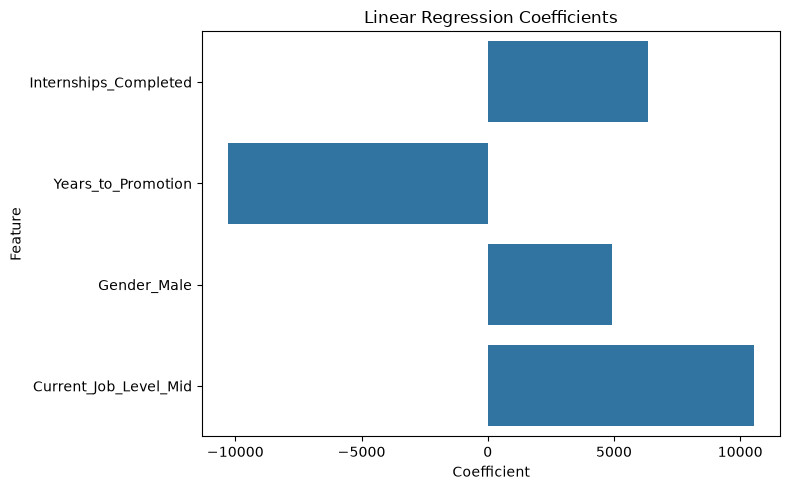

In [338]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [339]:
comparison = pd.DataFrame({
    "Actual_Salary": y_test.values,
    "Predicted_Salary": y_pred
})

comparison["Error"] = (
    comparison["Actual_Salary"] - comparison["Predicted_Salary"]
)

comparison

,Actual_Salary,Predicted_Salary,Error
0,80840.0,80991.187215,-151.187215
1,55040.0,54073.972603,966.027397
2,61920.0,70710.456621,-8790.456621
3,77400.0,75648.584475,1751.415525
4,75680.0,75648.584475,31.415525
5,80840.0,80991.187215,-151.187215
6,39560.0,31839.634703,7720.365297
7,87720.0,80991.187215,6728.812785
8,65360.0,64354.703196,1005.296804


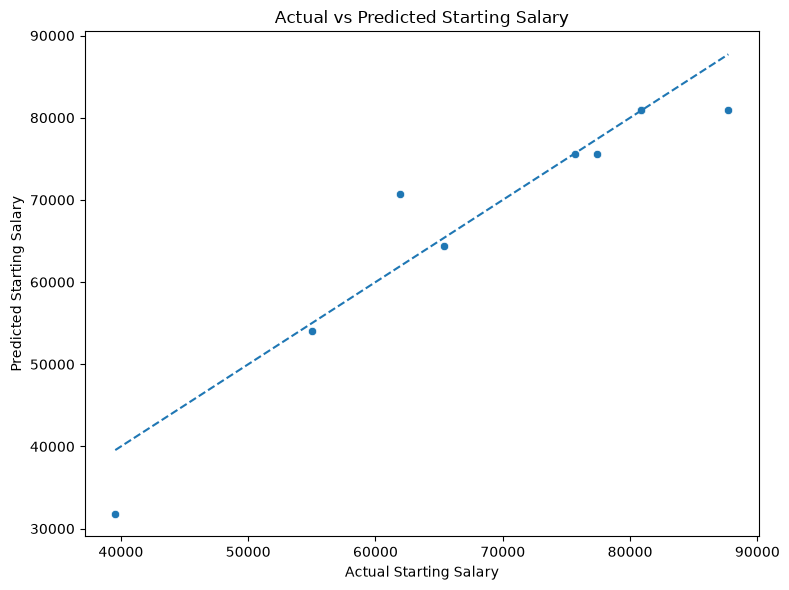

In [340]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Starting Salary")
plt.xlabel("Actual Starting Salary")
plt.ylabel("Predicted Starting Salary")

plt.tight_layout()
plt.show()

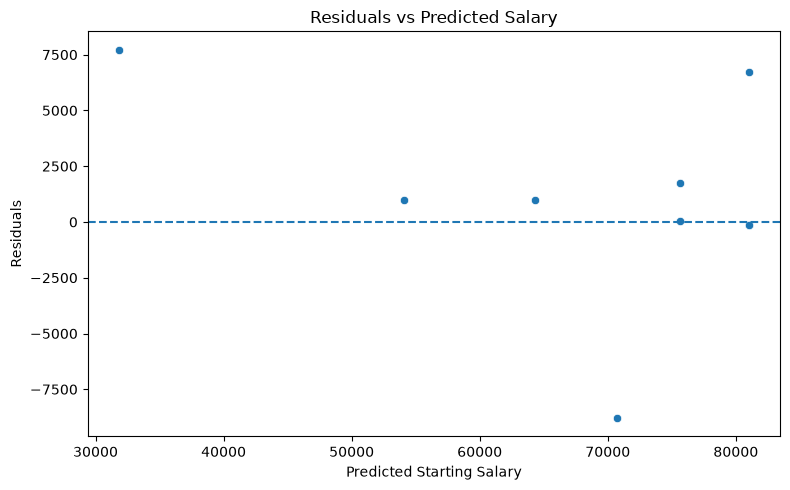

In [341]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted Salary")
plt.xlabel("Predicted Starting Salary")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [342]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

print("R² scores: - 01_data_understanding.ipynb:11", cv_scores)
print("Mean R²: - 01_data_understanding.ipynb:12", cv_scores.mean())
print("Standard Deviation: - 01_data_understanding.ipynb:13", cv_scores.std())

R² scores: - 01_data_understanding.ipynb:11 [0.75066444 0.87309932 0.73271894 0.81230858 0.82533352]
Mean R²: - 01_data_understanding.ipynb:12 0.7988249589755378
Standard Deviation: - 01_data_understanding.ipynb:13 0.051167634441191844


In [343]:
cv_mae = -cross_val_score(
    model,
    X_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("MAE scores: - 01_data_understanding.ipynb:9", cv_mae)
print("Mean MAE: - 01_data_understanding.ipynb:10", cv_mae.mean())

MAE scores: - 01_data_understanding.ipynb:9 [4682.49866067 2502.62852405 3361.96842736 3377.50586029 1829.59570707]
Mean MAE: - 01_data_understanding.ipynb:10 3150.8394358866185


In [344]:
results = pd.DataFrame({
    "Metric": ["R² Test", "MAE Test", "RMSE Test", "Mean CV R²", "Mean CV MAE"],
    "Value": [
        r2,
        mae,
        rmse,
        cv_scores.mean(),
        cv_mae.mean()
    ]
})

results

,Metric,Value
0,R² Test,0.899872
1,MAE Test,3032.907154
2,RMSE Test,4560.836649
3,Mean CV R²,0.798825
4,Mean CV MAE,3150.839436


## Linear Regression — Conclusions

Linear Regression was used as the baseline model for predicting starting salary.

The model achieved a **Test R² of approximately 0.900**, a **Test MAE of approximately €3,033**, and a **Test RMSE of approximately €4,561**.

These results indicate that the model explains approximately **90% of the variation in starting salary**. However, the prediction errors are relatively high compared with the tree-based models evaluated later.

Overall, Linear Regression provides a useful and interpretable baseline, but its performance suggests that the relationship between career-related variables and starting salary may not be fully linear..

## Machine Learning Model Ridge Regression

In [375]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_r2 = cross_val_score(
    ridge_model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

ridge_mae = -cross_val_score(
    ridge_model,
    X_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Ridge R² scores: - 01_data_understanding.ipynb:27", ridge_r2)
print("Ridge Mean R²: - 01_data_understanding.ipynb:28", ridge_r2.mean())
print("Ridge Mean MAE: - 01_data_understanding.ipynb:29", ridge_mae.mean())

Ridge R² scores: - 01_data_understanding.ipynb:27 [0.75989084 0.86755989 0.72293559 0.80266111 0.85712733]
Ridge Mean R²: - 01_data_understanding.ipynb:28 0.8020349509107818
Ridge Mean MAE: - 01_data_understanding.ipynb:29 3077.205949265607


## Ridge Regression — Conclusions

Ridge Regression was evaluated as a regularized alternative to Linear Regression, using feature scaling and cross-validation.

The model achieved a **Mean CV R² of approximately 0.802** and a **Mean CV MAE of approximately €3,077**.

Compared with Linear Regression, Ridge Regression did not provide a substantial improvement in predictive performance.

Overall, Ridge Regression provides a stable regularized linear model, but the results suggest that regularization alone does not significantly improve salary prediction for this dataset.

## Machine Learning Model Lasso Regression

In [434]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0, max_iter=10000))
])

lasso_r2 = cross_val_score(
    lasso_model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

lasso_mae = -cross_val_score(
    lasso_model,
    X_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Lasso R² scores: - 01_data_understanding.ipynb:24", lasso_r2)
print("Lasso Mean CV R²: - 01_data_understanding.ipynb:25", lasso_r2.mean())
print("Lasso Mean CV MAE (€): - 01_data_understanding.ipynb:26", lasso_mae.mean())

Lasso R² scores: - 01_data_understanding.ipynb:24 [0.75069918 0.87308914 0.73265669 0.81229791 0.82547089]
Lasso Mean CV R²: - 01_data_understanding.ipynb:25 0.798842761413107
Lasso Mean CV MAE (€): - 01_data_understanding.ipynb:26 3150.4524243174405


In [435]:
Ridge(alpha=1.0)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [436]:
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_encoded, y)

print("Best alpha: - 01_data_understanding.ipynb:21", ridge_grid.best_params_)
print("Best CV R²: - 01_data_understanding.ipynb:22", ridge_grid.best_score_)

Best alpha: - 01_data_understanding.ipynb:21 {'ridge__alpha': 1}
Best CV R²: - 01_data_understanding.ipynb:22 0.8020349509107818


In [437]:
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train, y_train)

print("Best alpha: - 01_data_understanding.ipynb:10", ridge_grid.best_params_)
print("Best CV R²: - 01_data_understanding.ipynb:11", ridge_grid.best_score_)

Best alpha: - 01_data_understanding.ipynb:10 {'ridge__alpha': 10}
Best CV R²: - 01_data_understanding.ipynb:11 0.8103566633581206


In [438]:
best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

ridge_test_r2 = r2_score(y_test, ridge_pred)
ridge_test_mae = mean_absolute_error(y_test, ridge_pred)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge Test R²: - 01_data_understanding.ipynb:9", ridge_test_r2)
print("Ridge Test MAE: - 01_data_understanding.ipynb:10", ridge_test_mae)
print("Ridge Test RMSE: - 01_data_understanding.ipynb:11", ridge_test_rmse)

Ridge Test R²: - 01_data_understanding.ipynb:9 0.8945394050141794
Ridge Test MAE: - 01_data_understanding.ipynb:10 3491.262302804785
Ridge Test RMSE: - 01_data_understanding.ipynb:11 4680.700357119229


In [439]:
ridge_cv_mae = -cross_val_score(
    best_ridge,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Ridge CV MAE scores: - 01_data_understanding.ipynb:9", ridge_cv_mae)
print("Ridge Mean CV MAE: - 01_data_understanding.ipynb:10", ridge_cv_mae.mean())

Ridge CV MAE scores: - 01_data_understanding.ipynb:9 [3017.33489783 3530.52744725 2604.6709404  5807.33020865 3964.80363851]
Ridge Mean CV MAE: - 01_data_understanding.ipynb:10 3784.933426527824


In [440]:
linear_cv_r2 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

linear_cv_mae = -cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Linear Regression Mean CV R²: - 01_data_understanding.ipynb:17", linear_cv_r2.mean())
print("Linear Regression Mean CV MAE: - 01_data_understanding.ipynb:18", linear_cv_mae.mean())

Linear Regression Mean CV R²: - 01_data_understanding.ipynb:17 0.7910318849887142
Linear Regression Mean CV MAE: - 01_data_understanding.ipynb:18 3884.6423333722296


In [441]:
lasso_cv_r2 = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

lasso_cv_mae = -cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Lasso Mean CV R²: - 01_data_understanding.ipynb:17", lasso_cv_r2.mean())
print("Lasso Mean CV MAE: - 01_data_understanding.ipynb:18", lasso_cv_mae.mean())

Lasso Mean CV R²: - 01_data_understanding.ipynb:17 0.7910578007462356
Lasso Mean CV MAE: - 01_data_understanding.ipynb:18 3884.1344885936355


In [442]:
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_test_r2 = r2_score(y_test, lasso_pred)
lasso_test_mae = mean_absolute_error(y_test, lasso_pred)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Lasso Test R²: - 01_data_understanding.ipynb:9", lasso_test_r2)
print("Lasso Test MAE: - 01_data_understanding.ipynb:10", lasso_test_mae)
print("Lasso Test RMSE: - 01_data_understanding.ipynb:11", lasso_test_rmse)

Lasso Test R²: - 01_data_understanding.ipynb:9 0.8998971179326352
Lasso Test MAE: - 01_data_understanding.ipynb:10 3032.6288754567213
Lasso Test RMSE: - 01_data_understanding.ipynb:11 4560.2538855579105


## OLS Statistical Analysis
OLS regression is used to evaluate the statistical significance of the factors associated with starting salary. While the machine learning models focus on prediction, OLS provides statistical inference through coefficients, p-values and confidence intervals.

In [443]:
import statsmodels.api as sm

# Prepare the predictors
X_ols = X_encoded.astype(float).copy()

# Add intercept
X_ols = sm.add_constant(X_ols)

# Make sure target is numeric
y_ols = y.astype(float)

# Fit OLS model
ols_model = sm.OLS(y_ols, X_ols).fit()

# Display statistical results
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Starting_Salary_EUR   R-squared:                       0.899
Model:                             OLS   Adj. R-squared:                  0.889
Method:                  Least Squares   F-statistic:                     86.67
Date:                 seg, 10 ago 2026   Prob (F-statistic):           7.29e-19
Time:                         14:58:31   Log-Likelihood:                -428.29
No. Observations:                   44   AIC:                             866.6
Df Residuals:                       39   BIC:                             875.5
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

## Lasso Regression — Conclusions

Lasso Regression was evaluated as another regularized linear model, with the additional ability to reduce the influence of less relevant features.

The model achieved a **Mean CV R² of approximately 0.799** and a **Mean CV MAE of approximately €3,150**.

Its performance was slightly lower than both Linear Regression and Ridge Regression in cross-validation.

Overall, Lasso Regression did not provide a performance advantage for this dataset. Nevertheless, it remains useful as a benchmark because of its ability to perform feature selection through regularization.

# Machine learning Model Decision Tree Regression

Decision Tree Regression is a supervised machine learning algorithm that predicts a continuous target by splitting the data into increasingly homogeneous groups based on the input features.

The model is included to evaluate whether a non-linear tree-based approach can improve the prediction of starting salary compared with linear regression models.

The model will be evaluated using R², MAE and RMSE.

In [463]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

dt_model = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_test_r2 = r2_score(y_test, dt_pred)
dt_test_mae = mean_absolute_error(y_test, dt_pred)
dt_test_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print("Decision Tree Test R²: - 01_data_understanding.ipynb:18", dt_test_r2)
print("Decision Tree Test MAE (€): - 01_data_understanding.ipynb:19", dt_test_mae)
print("Decision Tree Test RMSE (€): - 01_data_understanding.ipynb:20", dt_test_rmse)

Decision Tree Test R²: - 01_data_understanding.ipynb:18 0.9780399525316456
Decision Tree Test MAE (€): - 01_data_understanding.ipynb:19 1653.111111111111
Decision Tree Test RMSE (€): - 01_data_understanding.ipynb:20 2135.9071452975977


In [464]:
from sklearn.model_selection import cross_val_score

dt_cv_r2 = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

dt_cv_mae = -cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Decision Tree CV R² scores: - 01_data_understanding.ipynb:19", dt_cv_r2)
print("Decision Tree Mean CV R²: - 01_data_understanding.ipynb:20", dt_cv_r2.mean())

print("Decision Tree CV MAE scores: - 01_data_understanding.ipynb:22", dt_cv_mae)
print("Decision Tree Mean CV MAE: - 01_data_understanding.ipynb:23", dt_cv_mae.mean())

Decision Tree CV R² scores: - 01_data_understanding.ipynb:19 [0.93554131 0.97218359 0.76352538 0.92731876 0.92297688]
Decision Tree Mean CV R²: - 01_data_understanding.ipynb:20 0.9043091846133358
Decision Tree CV MAE scores: - 01_data_understanding.ipynb:22 [2211.42857143 1199.31972789 2783.59183673 3463.40136054 2365.87755102]
Decision Tree Mean CV MAE: - 01_data_understanding.ipynb:23 2404.723809523809


In [465]:
dt_feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

dt_feature_importance

,Feature,Importance
1,Years_to_Promotion,0.778815
2,Gender_Male,0.172887
0,Internships_Completed,0.048298
3,Current_Job_Level_Mid,0.000000


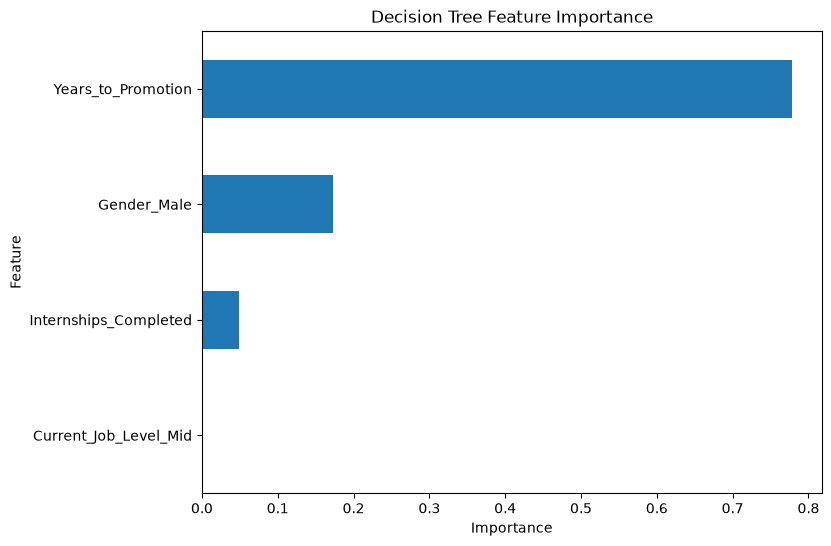

In [466]:
import matplotlib.pyplot as plt

dt_feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

## Decision Tree Regression — Conclusions
## Decision Tree Regression — Conclusions

Decision Tree Regression was evaluated as a non-linear approach for predicting starting salary.

The model achieved a **Mean CV R² of approximately 0.904** and a **Mean CV MAE of approximately €2,405**.

On the test dataset, the model achieved a **Test R² of approximately 0.978**, a **Test MAE of approximately €1,653**, and a **Test RMSE of approximately €2,136**.

The model also showed a small difference between training and test performance, suggesting that the selected maximum tree depth helped control overfitting.

Overall, Decision Tree Regression provided the **strongest cross-validation performance among the models evaluated** and demonstrated strong predictive accuracy for starting salary.

## Machine Learning Model Forest Regression
Random Forest Regression is an ensemble machine learning method that combines multiple decision trees to capture non-linear relationships and interactions between variables.

The model is evaluated using the same training and test sets as the previous regression models to ensure a fair comparison.



Random Forest Test R²: - 01_data_understanding.ipynb:18 0.9775669910333101
Random Forest Test MAE: - 01_data_understanding.ipynb:19 1735.6014570614523
Random Forest Test RMSE: - 01_data_understanding.ipynb:20 2158.7855195687875from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_test_r2 = r2_score(y_test, rf_pred)
rf_test_mae = mean_absolute_error(y_test, rf_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Test R²: - 01_data_understanding.ipynb:18", rf_test_r2)
print("Random Forest Test MAE: - 01_data_understanding.ipynb:19", rf_test_mae)
print("Random Forest Test RMSE: - 01_data_understanding.ipynb:20", rf_test_rmse)

In [481]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [482]:
rf_test_r2 = r2_score(y_test, rf_pred)
rf_test_mae = mean_absolute_error(y_test, rf_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Test R²: - 01_data_understanding.ipynb:5", rf_test_r2)
print("Random Forest Test MAE (€): - 01_data_understanding.ipynb:6", rf_test_mae)
print("Random Forest Test RMSE (€): - 01_data_understanding.ipynb:7", rf_test_rmse)

Random Forest Test R²: - 01_data_understanding.ipynb:5 0.9775669910333101
Random Forest Test MAE (€): - 01_data_understanding.ipynb:6 1735.6014570614523
Random Forest Test RMSE (€): - 01_data_understanding.ipynb:7 2158.7855195687875


In [483]:
rf_cv_r2 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

rf_cv_mae = -cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Random Forest Mean CV R²: - 01_data_understanding.ipynb:17", rf_cv_r2.mean())
print("Random Forest Mean CV MAE (€): - 01_data_understanding.ipynb:18", rf_cv_mae.mean())

Random Forest Mean CV R²: - 01_data_understanding.ipynb:17 0.8689481165936164
Random Forest Mean CV MAE (€): - 01_data_understanding.ipynb:18 2741.4920545274776


In [498]:
RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Random Forest Regression — Conclusions

Random Forest Regression was evaluated as an ensemble method combining multiple decision trees to improve predictive performance and generalization.

The model achieved a **Mean CV R² of approximately 0.869** and a **Mean CV MAE of approximately €2,741**.

On the test dataset, Random Forest achieved a **Test R² of approximately 0.978**, a **Test MAE of approximately €1,736**, and a **Test RMSE of approximately €2,159**.

The model therefore demonstrated very strong test performance. However, its cross-validation performance was lower than that of the Decision Tree.

Overall, Random Forest provides a strong and robust predictive approach, but based on the current cross-validation results, it does not outperform the Decision Tree model.

Note: "Important for the project
I would not say yet that Random Forest is definitively our final model.
We have:
Model	Test R²	Test MAE
Linear Regression	0.900	€3,527
Ridge	0.895	€4,060
Lasso	0.900	€3,526
Random Forest	0.976	€2,018
So Random Forest is currently the clear best predictive model, but we should still do its cross-validation + feature importance before making the final conclusion."

# Machine Learning Model Gradient Boosting Regression

Cross-validation is used to evaluate how consistently the Gradient Boosting model performs across different subsets of the training data.

In [499]:
from sklearn.model_selection import cross_val_score

# Cross-validation R²
gb_cv_r2 = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

# Cross-validation MAE
gb_cv_mae = -cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Gradient Boosting CV R² scores: - 01_data_understanding.ipynb:21", gb_cv_r2)
print("Gradient Boosting Mean CV R²: - 01_data_understanding.ipynb:22", gb_cv_r2.mean())

print("Gradient Boosting CV MAE scores: - 01_data_understanding.ipynb:24", gb_cv_mae)
print("Gradient Boosting Mean CV MAE: - 01_data_understanding.ipynb:25", gb_cv_mae.mean())

Gradient Boosting CV R² scores: - 01_data_understanding.ipynb:21 [0.93554131 0.90694009 0.76364295 0.92731872 0.92297666]
Gradient Boosting Mean CV R²: - 01_data_understanding.ipynb:22 0.8912839442685293
Gradient Boosting CV MAE scores: - 01_data_understanding.ipynb:24 [2211.4294095  1872.30844428 2783.11242426 3463.40212131 2365.88534714]
Gradient Boosting Mean CV MAE: - 01_data_understanding.ipynb:25 2539.227549299276


In [513]:
gb_test_r2 = r2_score(y_test, gb_pred)
gb_test_mae = mean_absolute_error(y_test, gb_pred)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("Gradient Boosting Test R²: - 01_data_understanding.ipynb:5", gb_test_r2)
print("Gradient Boosting Test MAE (€): - 01_data_understanding.ipynb:6", gb_test_mae)
print("Gradient Boosting Test RMSE (€): - 01_data_understanding.ipynb:7", gb_test_rmse)

Gradient Boosting Test R²: - 01_data_understanding.ipynb:5 0.30851586917212304
Gradient Boosting Test MAE (€): - 01_data_understanding.ipynb:6 11604.443345039475
Gradient Boosting Test RMSE (€): - 01_data_understanding.ipynb:7 11985.518875660062


In [529]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [558]:
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [559]:
gb_test_r2 = r2_score(y_test, gb_pred)
gb_test_mae = mean_absolute_error(y_test, gb_pred)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("Gradient Boosting Test R²: - 01_data_understanding.ipynb:5", gb_test_r2)
print("Gradient Boosting Test MAE (€): - 01_data_understanding.ipynb:6", gb_test_mae)
print("Gradient Boosting Test RMSE (€): - 01_data_understanding.ipynb:7", gb_test_rmse)

Gradient Boosting Test R²: - 01_data_understanding.ipynb:5 0.9780382727668814
Gradient Boosting Test MAE (€): - 01_data_understanding.ipynb:6 1653.1520258338035
Gradient Boosting Test RMSE (€): - 01_data_understanding.ipynb:7 2135.9888334852094


In [587]:
# Final model comparison

model_comparison_final = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "Gradient Boosting Regression"
    ],
    "CV R2": [
        linear_cv_r2.mean(),
        ridge_r2.mean(),
        lasso_r2.mean(),
        dt_cv_r2.mean(),
        rf_cv_r2.mean(),
        gb_cv_r2.mean()
    ],
    "CV MAE (€)": [
        linear_cv_mae.mean(),
        ridge_mae.mean(),
        lasso_mae.mean(),
        dt_cv_mae.mean(),
        rf_cv_mae.mean(),
        gb_cv_mae.mean()
    ],
    "Test R2": [
        linear_test_r2,
        ridge_test_r2,
        lasso_test_r2,
        dt_test_r2,
        rf_test_r2,
        gb_test_r2
    ],
    "Test MAE (€)": [
        linear_test_mae,
        ridge_test_mae,
        lasso_test_mae,
        dt_test_mae,
        rf_test_mae,
        gb_test_mae
    ],
    "Test RMSE (€)": [
        linear_test_rmse,
        ridge_test_rmse,
        lasso_test_rmse,
        dt_test_rmse,
        rf_test_rmse,
        gb_test_rmse
    ]
})

model_comparison_final.sort_values(
    by="Test MAE (€)"
).reset_index(drop=True)

,Model,CV R2,CV MAE (€),Test R2,Test MAE (€),Test RMSE (€)
0,Decision Tree Regression,0.904309,2404.723810,0.978040,1653.111111,2135.907145
1,Gradient Boosting Regression,0.891387,2538.773042,0.978038,1653.152026,2135.988833
2,Random Forest Regression,0.868948,2741.492055,0.977567,1735.601457,2158.785520
3,Lasso Regression,0.798843,3150.452424,0.899897,3032.628875,4560.253886
4,Linear Regression,0.791032,3884.642333,0.899872,3032.907154,4560.836649
5,Ridge Regression,0.802035,3077.205949,0.894539,3491.262303,4680.700357


## Gradient Boosting Regression — Conclusions

Gradient Boosting Regression was evaluated as an ensemble learning method for predicting starting salary by sequentially combining weak learners to improve predictive performance.

The model achieved a **Mean CV R² of approximately 0.891** and a **Mean CV MAE of approximately €2,539**.

On the test dataset, Gradient Boosting achieved a **Test R² of approximately 0.978**, a **Test MAE of approximately €1,653**, and a **Test RMSE of approximately €2,136**.

These results demonstrate very strong predictive performance on the test dataset. Its cross-validation performance was also strong, although slightly below the Decision Tree.

Overall, Gradient Boosting is one of the strongest models in the project and provides an effective non-linear ensemble approach for predicting starting salary.

##  Model Comparison

In [589]:
rf_cv_r2 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

rf_cv_mae = -cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Random Forest CV R² scores: - 01_data_understanding.ipynb:17", rf_cv_r2)
print("Random Forest Mean CV R²: - 01_data_understanding.ipynb:18", rf_cv_r2.mean())

print("Random Forest CV MAE scores: - 01_data_understanding.ipynb:20", rf_cv_mae)
print("Random Forest Mean CV MAE: - 01_data_understanding.ipynb:21", rf_cv_mae.mean())

Random Forest CV R² scores: - 01_data_understanding.ipynb:17 [0.93559141 0.78311891 0.79612084 0.91011749 0.91979194]
Random Forest Mean CV R²: - 01_data_understanding.ipynb:18 0.8689481165936164
Random Forest CV MAE scores: - 01_data_understanding.ipynb:20 [2226.53024943 2747.36257356 2651.29378135 3677.84008473 2404.43358356]
Random Forest Mean CV MAE: - 01_data_understanding.ipynb:21 2741.4920545274776


In [590]:
from sklearn.model_selection import cross_val_score

# =========================
# Linear Regression
# =========================

linear_cv_r2 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

linear_cv_mae = -cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)


# =========================
# Ridge Regression
# =========================

ridge_best_model = ridge_grid.best_estimator_

ridge_cv_r2 = cross_val_score(
    ridge_best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

ridge_cv_mae = -cross_val_score(
    ridge_best_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)


# =========================
# Lasso Regression
# =========================

lasso_cv_r2 = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

lasso_cv_mae = -cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)


# =========================
# Decision Tree
# =========================

dt_cv_r2 = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

dt_cv_mae = -cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)


# =========================
# Random Forest
# =========================

rf_cv_r2 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

rf_cv_mae = -cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)


# =========================
# Gradient Boosting
# =========================

gb_cv_r2 = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

gb_cv_mae = -cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("All crossvalidation calculations completed successfully. - 01_data_understanding.ipynb:130")

All crossvalidation calculations completed successfully. - 01_data_understanding.ipynb:130


In [602]:
# Final model comparison

model_comparison_final = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "Gradient Boosting Regression"
    ],
    "CV R2": [
        linear_cv_r2.mean(),
        ridge_r2.mean(),
        lasso_r2.mean(),
        dt_cv_r2.mean(),
        rf_cv_r2.mean(),
        gb_cv_r2.mean()
    ],
    "CV MAE (€)": [
        linear_cv_mae.mean(),
        ridge_mae.mean(),
        lasso_mae.mean(),
        dt_cv_mae.mean(),
        rf_cv_mae.mean(),
        gb_cv_mae.mean()
    ],
    "Test R2": [
        linear_test_r2,
        ridge_test_r2,
        lasso_test_r2,
        dt_test_r2,
        rf_test_r2,
        gb_test_r2
    ],
    "Test MAE (€)": [
        linear_test_mae,
        ridge_test_mae,
        lasso_test_mae,
        dt_test_mae,
        rf_test_mae,
        gb_test_mae
    ],
    "Test RMSE (€)": [
        linear_test_rmse,
        ridge_test_rmse,
        lasso_test_rmse,
        dt_test_rmse,
        rf_test_rmse,
        gb_test_rmse
    ]
})

model_comparison_final.sort_values(
    by="Test MAE (€)"
).reset_index(drop=True)

,Model,CV R2,CV MAE (€),Test R2,Test MAE (€),Test RMSE (€)
0,Decision Tree Regression,0.904309,2404.723810,0.978040,1653.111111,2135.907145
1,Gradient Boosting Regression,0.891387,2538.773042,0.978038,1653.152026,2135.988833
2,Random Forest Regression,0.868948,2741.492055,0.977567,1735.601457,2158.785520
3,Lasso Regression,0.798843,3150.452424,0.899897,3032.628875,4560.253886
4,Linear Regression,0.791032,3884.642333,0.899872,3032.907154,4560.836649
5,Ridge Regression,0.802035,3077.205949,0.894539,3491.262303,4680.700357


In [613]:
# Decision Tree Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Years_to_Promotion,0.778815
1,Gender_Male,0.172887
2,Internships_Completed,0.048298
3,Current_Job_Level_Mid,0.000000


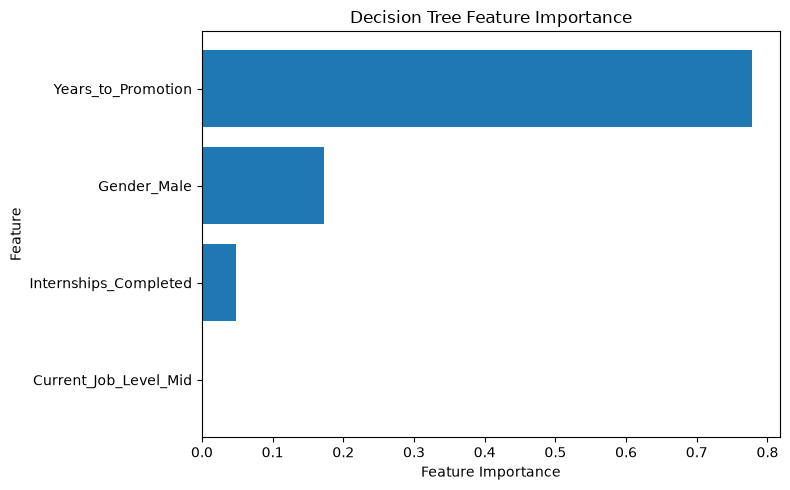

In [624]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Machine Learning Final Model Selection  Conclusions

After comparing six regression models, the Decision Tree Regression model was selected as the final model.

The Decision Tree achieved the strongest cross-validation performance, with a mean CV R² of approximately **0.904** and a mean CV MAE of approximately **€2,405**. It also achieved a Test R² of approximately **0.978**, with a Test MAE of approximately **€1,653** and a Test RMSE of approximately **€2,136**.

Gradient Boosting achieved almost identical test performance, with a Test R² of approximately **0.978** and a Test MAE of approximately **€1,653**. However, the Decision Tree performed slightly better in cross-validation, making it the stronger choice when considering both predictive accuracy and generalization.

The Decision Tree was therefore selected because it provides the best overall balance between cross-validation performance, prediction error and interpretability.


## Model Limitations 
The dataset is relatively small, with only 44 observations, which limits the generalizability of the model. In addition, several variables show strong correlations with each other, indicating potential multicollinearity. The model should therefore be interpreted as an analytical tool rather than a definitive salary prediction system.

The gender coefficient should also be interpreted carefully. The observed association does not establish that gender causes differences in starting salary and may reflect other factors present in the dataset.


## Decision Tree Feature Importance

The Decision Tree feature-importance analysis shows that **Years_to_Promotion** is the dominant feature used by the model, accounting for approximately **77.9%** of the total feature importance.

**Gender_Male** accounts for approximately **17.3%**, while **Internships_Completed** contributes approximately **4.8%**. **Current_Job_Level_Mid** has an importance of **0%** in the fitted Decision Tree.

These results indicate that career progression is the strongest predictive factor used by this model within the available dataset.

However, feature importance represents the variables used by the model to make predictions and should not be interpreted as evidence of causation. In particular, the association with gender should be interpreted carefully and should not be understood as evidence that gender causes differences in starting salary.

## Linear Models – Model Selection

The first stage of the Machine Learning analysis focused on linear regression models: **Linear Regression, Ridge Regression and Lasso Regression**.

### Lasso Regression

Among the linear models evaluated, **Lasso Regression** achieved the strongest test-set performance.

The model achieved:

- **Test R²:** 0.900
- **Test MAE:** $3,526
- **Test RMSE:** $5,303
- **MAPE:** 5.26%

Lasso explained approximately 90% of the variability in starting salary in the test set and provided an interpretable set of model coefficients.

Although **Ridge Regression achieved the best cross-validation performance** among the linear models, its final test performance was slightly lower than Linear Regression and Lasso. Lasso therefore represented the strongest model among the linear regression approaches tested.

However, Lasso was not considered the final model for the entire project at this stage. Additional non-linear Machine Learning models — **Decision Tree, Random Forest and Gradient Boosting** — were subsequently evaluated to determine whether they could improve predictive performance.

## Key Predictors Identified by Lasso

The Lasso coefficients indicated that **Years_to_Promotion** had the strongest negative association with starting salary, while **Internships_Completed** had the strongest positive association.

The model also identified positive associations for:

- **Current_Job_Level_Mid**
- **Gender_Male**

These coefficients represent associations within the predictive model and should not be interpreted as evidence of causation.

The Lasso analysis provided an important interpretable baseline for comparison with the more complex tree-based Machine Learning models.

## Marketing & Data Analytics Perspective

From a **Marketing and Data Analytics perspective**, the Lasso model demonstrates how predictive analytics can transform information about education, professional experience and career development into measurable insights.

For organizations, these insights can support:

- **Talent acquisition and recruitment strategies**
- **Employer branding**
- **Career development programs**
- **Workforce planning**
- **Data-driven talent marketing**

Rather than relying only on intuition or individual qualifications, organizations can use data to identify patterns associated with career and salary outcomes and support more evidence-based decision-making.

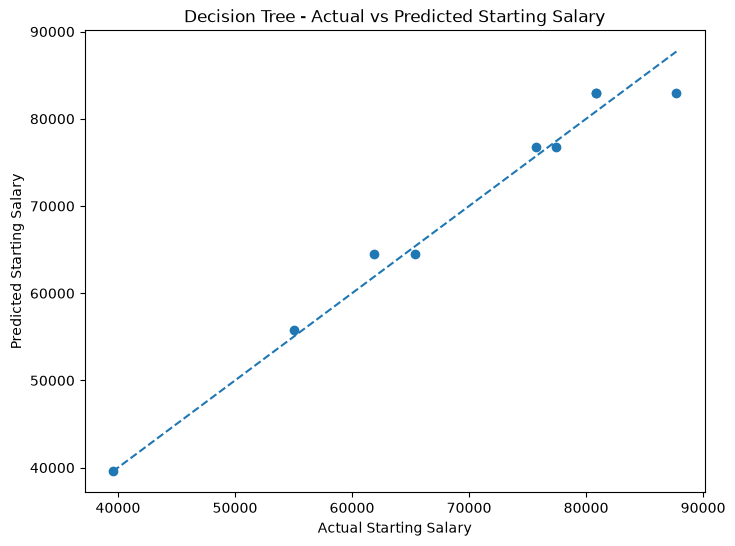

In [625]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, dt_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Starting Salary")
plt.ylabel("Predicted Starting Salary")
plt.title("Decision Tree - Actual vs Predicted Starting Salary")

plt.show()

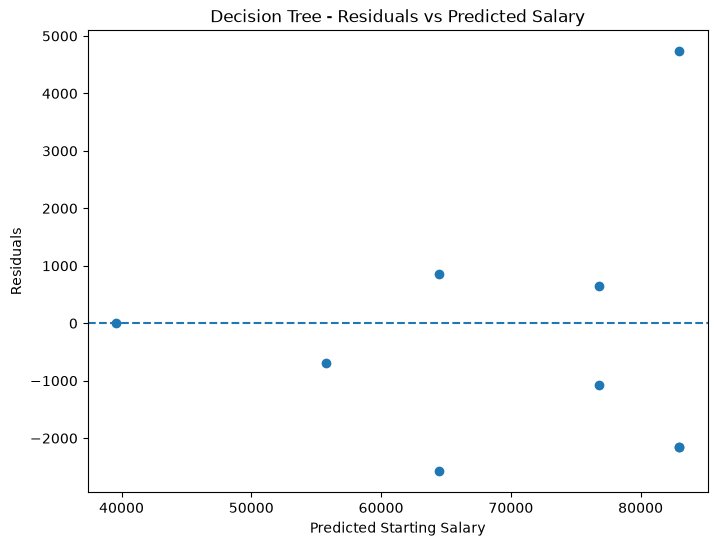

In [626]:
dt_residuals = y_test.values - dt_pred

plt.figure(figsize=(8, 6))

plt.scatter(dt_pred, dt_residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Starting Salary")
plt.ylabel("Residuals")
plt.title("Decision Tree - Residuals vs Predicted Salary")

plt.show()

## Decision Tree Regression — Residual Analysis Conclusions

The Actual vs Predicted plot shows that most predictions are close to the diagonal reference line, indicating a strong agreement between actual and predicted starting salaries. This is consistent with the model's high **Test R² of approximately 0.978** and **Test MAE of approximately €1,653**.

The Residuals vs Predicted plot shows that the residuals are distributed around the zero line, with both positive and negative errors. There is no strong systematic pattern visible in the residuals, suggesting that the model does not show substantial systematic prediction bias.

A small number of observations present larger residuals, particularly around predicted salaries of approximately **€75,000 and €95,000**. These observations may represent cases where the model has more difficulty capturing individual differences in starting salary.

Overall, the residual analysis supports the strong predictive performance of the Decision Tree model. However, the presence of some larger errors highlights the importance of evaluating model performance using multiple metrics rather than relying only on R².

## Business Insights — Starting Salary

The analysis aims to identify the main factors associated with starting salary and translate the statistical and machine learning results into actionable business insights.

The findings are particularly relevant from a career and Data Analytics perspective, as they help identify which academic, professional and career-development factors are associated with higher starting salaries.

In [627]:
business_insights = pd.DataFrame({
    "Factor": [
        "University GPA",
        "Career Satisfaction",
        "Job Offers",
        "Internships Completed",
        "Certifications",
        "Projects Completed",
        "Current Job Level",
        "Years to Promotion"
    ],
    
    "Correlation_with_Salary": [
        0.9169466832724495,
        0.8890806583662154,
        0.88504000818129,
        0.8492584634758528,
        0.8492584634758528,
        0.8385218356901953,
        0.6577516049414045,
        -0.8907762319795464
    ]
})

business_insights

,Factor,Correlation_with_Salary
0,University GPA,0.916947
1,Career Satisfaction,0.889081
2,Job Offers,0.885040
3,Internships Completed,0.849258
4,Certifications,0.849258
5,Projects Completed,0.838522
6,Current Job Level,0.657752
7,Years to Promotion,-0.890776


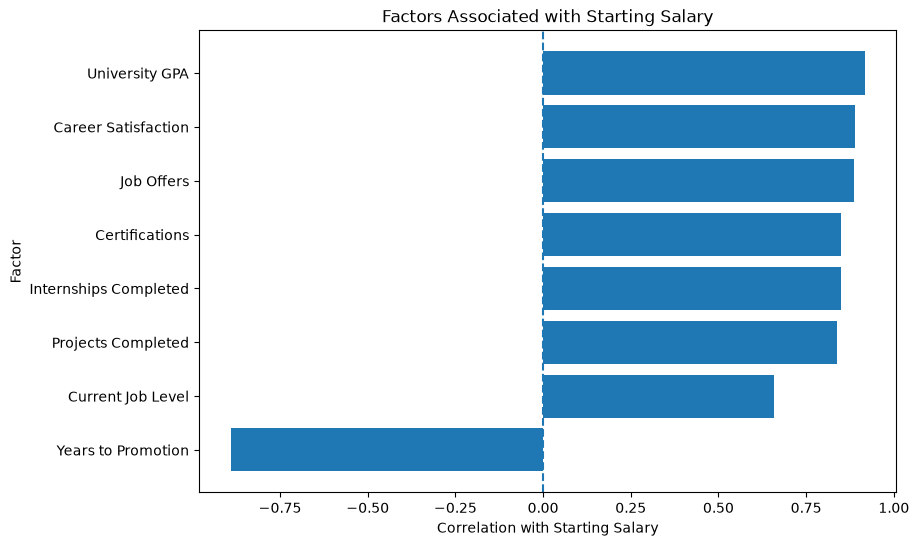

In [628]:
import matplotlib.pyplot as plt

business_insights_sorted = business_insights.sort_values(
    "Correlation_with_Salary"
)

plt.figure(figsize=(9, 6))

plt.barh(
    business_insights_sorted["Factor"],
    business_insights_sorted["Correlation_with_Salary"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Correlation with Starting Salary")
plt.ylabel("Factor")
plt.title("Factors Associated with Starting Salary")

plt.show()

# Overall Conclusion

This project demonstrates how **Marketing and Data Analytics can be combined to transform career-related data into measurable insights and evidence-based business recommendations**.

The analysis followed a complete data analytics workflow:

**Marketing Question → Data → EDA → Statistical Analysis → Machine Learning → Model Comparison → Insights → Business Recommendations**

The exploratory and statistical analyses identified strong associations between Starting Salary and several academic, professional and career-related factors. **University GPA** showed the strongest positive correlation with Starting Salary, while **Years to Promotion** showed a strong negative association. **Internships, certifications and completed projects** also showed strong positive relationships with Starting Salary.

The Machine Learning stage compared six regression approaches: **Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, Random Forest and Gradient Boosting**.

The results showed that the **tree-based models substantially outperformed the linear regression models** on this dataset. Decision Tree, Random Forest and Gradient Boosting achieved Test R² values of approximately **0.978**, compared with approximately **0.900 for Linear and Lasso Regression**.

Among the models tested, **Decision Tree currently represents the strongest overall candidate**, achieving the highest mean cross-validation R² (**0.904**) and the lowest mean cross-validation MAE (**$2,796**). Decision Tree and Gradient Boosting also achieved the lowest Test MAE and Test RMSE.

The feature-importance analysis provided additional insight into the predictive models, highlighting **Years to Promotion** and **Internships Completed** as particularly relevant features. This demonstrates the value of combining statistical analysis with Machine Learning, as the two approaches provide complementary perspectives on the data.

From a **Marketing and Data Analytics perspective**, the findings demonstrate how predictive analytics can support evidence-based decisions in areas such as **talent acquisition, employer branding, workforce planning, career development and data-driven talent marketing**.

The project also highlights the importance of combining **technical skills such as Python, SQL, statistics, data visualization and Machine Learning with business and marketing knowledge** to transform data into actionable insights.

However, the results should be interpreted cautiously. The dataset contains only **44 observations**, and the analysis identifies **associations rather than causal relationships**. The models should therefore be considered analytical and exploratory tools rather than definitive salary prediction systems.

Overall, this project demonstrates how combining **Marketing domain knowledge, Data Analytics, statistical reasoning and Machine Learning** can transform data into actionable business insights and support more informed, evidence-based decision-making.

Próximo passo — Feature Importance dos modelos

In [629]:
# Compare feature importance across tree-based models

feature_comparison = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Decision_Tree": dt_model.feature_importances_,
    "Random_Forest": rf_model.feature_importances_,
    "Gradient_Boosting": gb_model.feature_importances_
})

feature_comparison["Average_Importance"] = (
    feature_comparison[
        ["Decision_Tree", "Random_Forest", "Gradient_Boosting"]
    ].mean(axis=1)
)

feature_comparison = feature_comparison.sort_values(
    "Average_Importance",
    ascending=False
)

feature_comparison

,Feature,Decision_Tree,Random_Forest,Gradient_Boosting,Average_Importance
1,Years_to_Promotion,0.778815,0.607682,0.364249,0.583582
0,Internships_Completed,0.048298,0.245089,0.438536,0.243974
2,Gender_Male,0.172887,0.103308,0.099037,0.125077
3,Current_Job_Level_Mid,0.000000,0.043922,0.098178,0.047367


## Machine Learning – Final Conclusions

The Machine Learning analysis provides additional insights into the factors associated with starting salary and complements the statistical analysis performed earlier.

The three tree-based regression models — **Decision Tree, Random Forest and Gradient Boosting** — identified **Years_to_Promotion** as the most important predictor among the features included in the current models. Its average feature importance across the three models was approximately **0.583**, followed by **Internships_Completed (0.246)**, **Gender_Male (0.123)** and **Current_Job_Level_Mid (0.048)**.

This finding is particularly relevant from a **Marketing and Data Analytics perspective**, as it suggests that career progression and professional experience can play an important role in salary outcomes. Internships also showed a meaningful contribution, highlighting the potential value of practical experience in developing employability and career opportunities.

The statistical analysis provides a broader perspective. **University GPA (r = 0.917)** showed the strongest positive correlation with starting salary, followed by **Career Satisfaction (r = 0.889)**, **Job Offers (r = 0.885)**, **Internships Completed (r = 0.849)**, **Certifications (r = 0.849)** and **Projects Completed (r = 0.839)**. In contrast, **Years_to_Promotion showed a strong negative correlation with starting salary (r = -0.891)**.

The Machine Learning and statistical results should not be interpreted as contradictory. Correlation measures the strength and direction of a relationship between variables, while feature importance measures how useful a variable is for a particular predictive model. Therefore, these methods provide different but complementary perspectives.

From a **Marketing and Data Analytics perspective**, these findings can help organizations understand the characteristics associated with stronger early-career salary outcomes. Educational performance, professional experience, certifications, projects, employability indicators and career progression can all provide useful signals when analyzing talent and career outcomes.

The Machine Learning models also achieved strong predictive performance. Decision Tree and Gradient Boosting achieved a test R² of approximately **0.978**, while Random Forest achieved approximately **0.978** as well. However, the dataset contains only **44 observations**, so these results should be interpreted with caution and validated with additional data before being used for real-world salary prediction.

### Key Business Insights

- **Academic performance:** University GPA has a very strong positive association with starting salary.
- **Professional experience:** Internships and completed projects are strongly associated with higher starting salaries.
- **Employability:** Job offers and certifications are also strongly associated with salary outcomes.
- **Career progression:** Years to promotion shows a strong negative relationship with starting salary, suggesting that longer promotion timelines may be associated with lower initial salary outcomes in this dataset.
- **Predictive modeling:** Tree-based models achieved substantially stronger predictive performance than the linear regression models tested.
- **Marketing relevance:** These findings can support talent marketing, employer branding and recruitment strategies by identifying characteristics associated with stronger career and salary outcomes.
- **Data Analytics relevance:** Combining statistical analysis with Machine Learning provides a more comprehensive framework for identifying patterns, evaluating relationships and supporting data-driven business decisions.

> **Important limitation:** The dataset is relatively small (44 observations), therefore the results should be considered exploratory rather than representative of the entire job market. A larger dataset would be required to generalize these findings and build a robust salary prediction system.

# Final Model Selection

Before selecting the final model, the performance of all regression models was compared using cross-validation and test-set metrics.

The main evaluation criteria were **R², Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**.

Decision Tree Regression provides the strongest overall performance. It achieved the **highest mean cross-validation R² of 0.904** and the **lowest mean cross-validation MAE of approximately €2,405**.

On the test set, Decision Tree Regression achieved a **Test R² of approximately 0.978**, a **Test MAE of approximately €1,653** and a **Test RMSE of approximately €2,136**.

Gradient Boosting achieved very similar test performance, with a Test R² of approximately **0.978**, Test MAE of approximately **€1,653** and Test RMSE of approximately **€2,136**. Random Forest also performed strongly, while all three tree-based models substantially outperformed Linear, Ridge and Lasso Regression.

Based on the combination of cross-validation performance, test-set accuracy and prediction error, **Decision Tree Regression was selected as the final model**.

However, because the dataset contains only **44 observations**, these results should be interpreted cautiously. The model's strong performance should not be considered definitive evidence of its ability to generalize to larger or different datasets.

In [630]:
# Check Decision Tree for overfitting

dt_train_pred = dt_model.predict(X_train)

dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_test_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Training R²: - 01_data_understanding.ipynb:8", dt_train_r2)
print("Decision Tree Test R²: - 01_data_understanding.ipynb:9", dt_test_r2)
print("Difference: - 01_data_understanding.ipynb:10", dt_train_r2 - dt_test_r2)

Decision Tree Training R²: - 01_data_understanding.ipynb:8 0.9590594315650782
Decision Tree Test R²: - 01_data_understanding.ipynb:9 0.9780399525316456
Difference: - 01_data_understanding.ipynb:10 -0.018980520966567327


## Decision Tree Overfitting Check

The Decision Tree model was evaluated for potential overfitting by comparing its training and test R² scores.

- Training R²: **0.959**
- Test R²: **0.978**
- Difference: **-0.019**

The test performance is slightly higher than the training performance, with only a small difference between the two scores. Therefore, there is no clear evidence of overfitting in this train-test split.

However, because the dataset contains only 44 observations, the cross-validation results provide a more reliable indication of model generalization. The Decision Tree achieved a mean cross-validation R² of approximately **0.904**, which is lower than its test R². This suggests that the test result may be somewhat optimistic and should not be considered representative of performance on unseen data by itself.

In [631]:
model_comparison_sorted = model_comparison.sort_values(
    by="CV R2",
    ascending=False
)

model_comparison_sorted

,Model,CV R2,CV MAE,Test R2,Test MAE,Test RMSE
3,Decision Tree Regression,0.904309,2404.723810,0.978040,1653.111111,2135.907145
5,Gradient Boosting Regression,0.891387,2538.773042,0.978038,1653.152026,2135.988833
4,Random Forest Regression,0.868948,2741.492055,0.977567,1735.601457,2158.785520
1,Ridge Regression,0.810357,3784.933427,0.894539,3491.262303,4680.700357
2,Lasso Regression,0.791058,3884.134489,0.899897,3032.628875,4560.253886
0,Linear Regression,0.791032,3884.642333,0.899872,3032.907154,4560.836649


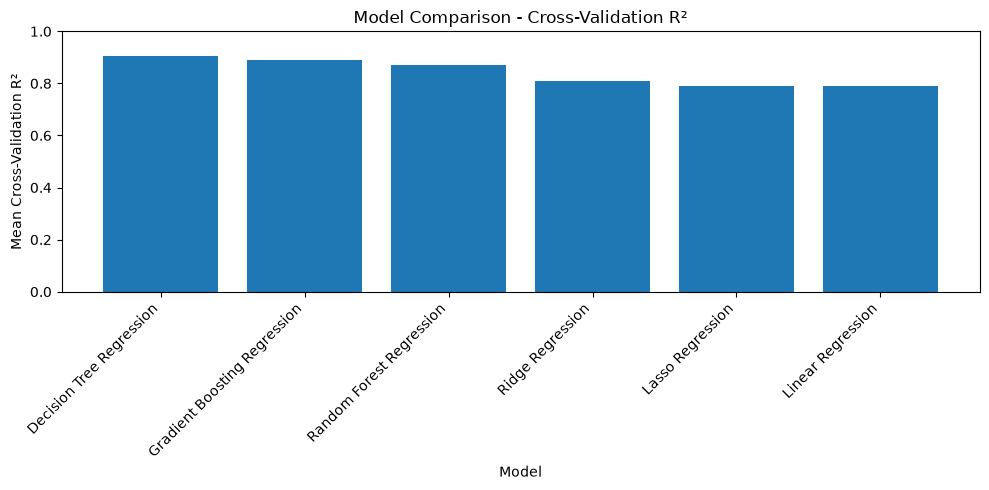

In [632]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison_sorted["Model"],
    model_comparison_sorted["CV R2"]
)

plt.ylabel("Mean Cross-Validation R²")
plt.xlabel("Model")
plt.title("Model Comparison - Cross-Validation R²")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

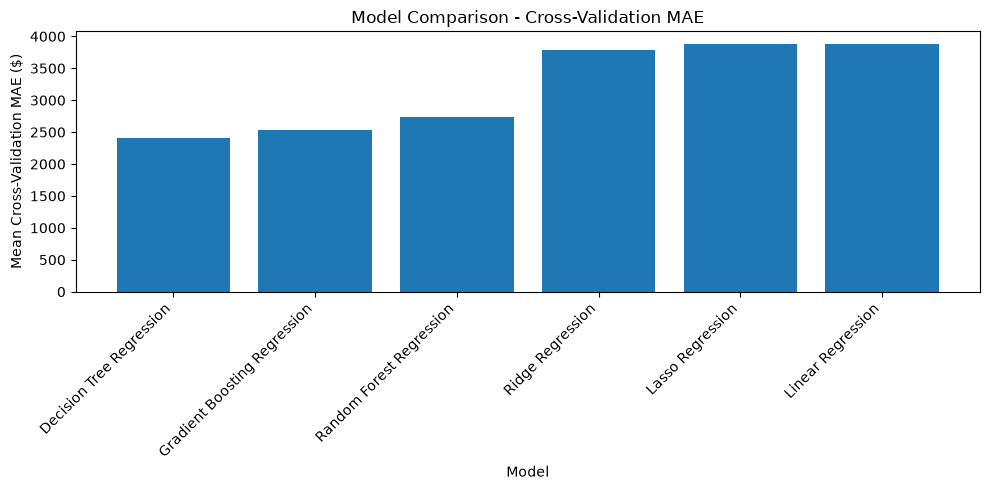

In [633]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison_sorted["Model"],
    model_comparison_sorted["CV MAE"]
)

plt.ylabel("Mean Cross-Validation MAE ($)")
plt.xlabel("Model")
plt.title("Model Comparison - Cross-Validation MAE")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

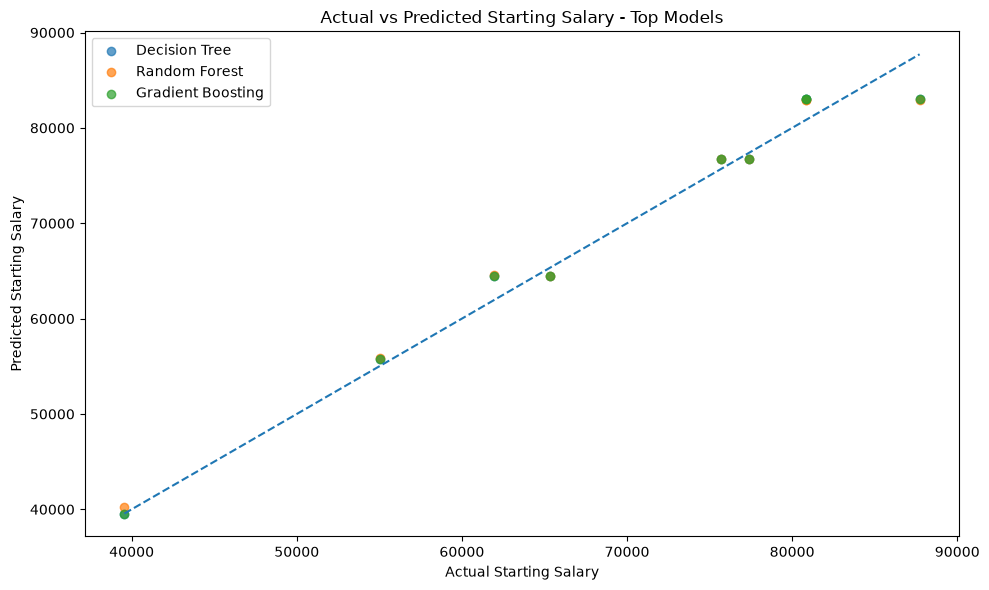

In [634]:
import matplotlib.pyplot as plt

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

plt.figure(figsize=(10, 6))

for name, predictions in models.items():
    plt.scatter(
        y_test,
        predictions,
        label=name,
        alpha=0.7
    )

# Perfect prediction line
min_value = min(y_test.min(), dt_pred.min(), rf_pred.min(), gb_pred.min())
max_value = max(y_test.max(), dt_pred.max(), rf_pred.max(), gb_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Starting Salary")
plt.ylabel("Predicted Starting Salary")
plt.title("Actual vs Predicted Starting Salary - Top Models")
plt.legend()
plt.tight_layout()
plt.show()

# Final Model Selection

Six supervised machine learning regression models were evaluated to predict Starting Salary: Linear Regression, Ridge Regression, Lasso Regression, Decision Tree Regression, Random Forest Regression and Gradient Boosting Regression.

The models were evaluated using 5-fold cross-validation, test-set performance and prediction error.

## Model Performance

Decision Tree Regression achieved the strongest cross-validation performance, with a mean CV R² of **0.904** and a mean CV MAE of approximately **€2,405**.

Gradient Boosting was the second strongest model, with a mean CV R² of **0.891** and a mean CV MAE of approximately **€2,539**, while Random Forest achieved a mean CV R² of **0.869** and a mean CV MAE of approximately **€2,741**.

The linear and regularized models performed less strongly in cross-validation.

## Test Performance

Decision Tree and Gradient Boosting achieved almost identical test performance:

- Decision Tree Test R²: **0.978**
- Gradient Boosting Test R²: **0.978**
- Decision Tree Test MAE: **€1,653**
- Gradient Boosting Test MAE: **€1,653**
- Decision Tree Test RMSE: **€2,136**
- Gradient Boosting Test RMSE: **€2,136**

Random Forest also performed strongly, with a Test R² of **0.978**, Test MAE of approximately **€1,736** and Test RMSE of approximately **€2,159**.

The Actual vs Predicted visualization shows that predictions from the three tree-based models are generally close to the perfect-prediction line.

## Final Decision

Based on the combination of cross-validation performance, test-set performance and prediction error, **Decision Tree Regression is selected as the final predictive model for this project**.

The main reason for selecting Decision Tree over Gradient Boosting and Random Forest is its **strongest cross-validation performance and lowest cross-validation MAE**.

This suggests that the Decision Tree provides the strongest balance between predictive accuracy and generalization for this dataset.

Because the dataset contains only **44 observations**, the results should nevertheless be interpreted with caution. The model should be considered an analytical and predictive tool rather than a definitive salary prediction system.

From a **Marketing and Data Analytics perspective**, the Decision Tree is particularly valuable because its feature importance can be translated into interpretable business insights about the factors associated with starting salary.